# Summaries for ELFI


The max number of BSI cases caused by the clade of interest.

The time of the max number of BSI cases.


Potential problems: elfi might want to have an observed sequence - I doubt I can input a summary statistic there directly.


New ideas 13.12.2023:
- Aggregate SIR simulation s.t. we have the sum of BSI cases over the year.
- S1: Compare tangent of observed BSI with SIR+obs model
- S2: Maximum of BSI observations


TODO
- Implement sum of BSI cases
- Implement S1 and S2
- Test S1 and S2


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load NORM data

norm_data = pd.read_excel("data/mmc2.xlsx", engine = 'openpyxl') # this is the NORM data


# load BSAC data
bsac_data = pd.read_csv("data/Supplemental_Data_S1.csv")


df = norm_data


# load babybiome data
or_data = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")


# load population data

norway_pop_data = pd.read_csv("data/Norway_population_2002-2017.csv", sep = '\t', header = 0, index_col = 0)


# load age distribution data
ages = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90-99", "100-109"]
groups = [61, 22, 67, 97, 131, 255, 556, 767, 900, 316, 3]

norm_age_data = pd.DataFrame(data={"age":ages, "n_BSI":groups})

In [3]:
bsac_data.head()

,ERS accession,ERR accession,Collection,BSAC_or_CUH_number,Year_of_isolation,Sequencing depth,MLST,Phylogroup,serotype,H30Rx,...,oqxA_1_EU370913,oqxB_1_EU370913,qepA_1_AB263754,strA_1_M96392,strB_1_M96392,sul1_11_DQ914960,sul2_1_AF542061,sul3_2_AJ459418,tetA_2_X00006,tetB_3_AP000342
0,ERS357183,ERR435312,BSAC,eo100,2001,76.628483,68,D,NA:H6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tetB_4_AF326777
1,ERS357556,ERR434919,BSAC,eo1011,2005,78.691295,652,A,NA:H9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ERS357557,ERR434399,BSAC,eo1013,2005,84.620679,95,B2,O1:H7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ERS357558,ERR434695,BSAC,eo1014,2005,76.405329,73,B2,O6:H1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ERS357559,ERR434696,BSAC,eo1015,2005,75.694181,73,B2,O6:H1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summaries for observed data

In [4]:
# extract the maximum number of BSI cases and the year this occured by clade

def get_obs_BSI(df, clade,  cladecol = 'CC131_clades', yearcol = "year", as_prop = True):
    # Get the proportion of clade out of all observations per year
    # note: this is not age group specific, just the overall number of BSI cases per year.
    # But: I could multiply to get the BSI observations by the age group of interest - provided that the distribution of different clades is the same from one age group to another.
    
    if 'clade' in df.columns:
        cladecol = 'clade'
        
    if as_prop:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade][yearcol])/pd.value_counts(df[yearcol])# n clades per year/n all ST131 obs
    else:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade][yearcol]) # these are counts directly
    
    return theta_BSI_obs

bsi_norm_obs = get_obs_BSI(norm_data, clade = "A", cladecol = 'CC131_clades', yearcol = "year")
bsi_bsac_obs = get_obs_BSI(bsac_data, clade = "A", cladecol = 'Phylogroup', yearcol = "Year_of_isolation")

In [5]:
type(bsi_norm_obs)

pandas.core.series.Series

In [6]:
def print_BSI_obs_summary(bsi_obs):
    # Print the max amount of BSI cases and the year this occured.
    
    max_bsi = max(bsi_obs)
    max_year = bsi_obs[bsi_obs == max_bsi].index[0]
    delta_years = max_year - min(bsi_obs.index)
    print(f'The maximum (n or prop) of BSI cases is {max_bsi} in {max_year}.')
    print(f'This is {delta_years} years from the start of the study period ({min(bsi_obs.index)}).')

def get_BSI_obs_summaries(bsi_obs, is_weekly = False):
    # Return the max prop of BSI cases between the study period and the time from the beginning of study to that moment
    
    max_bsi = max(bsi_obs)
    max_year = bsi_obs[bsi_obs == max_bsi].index[0]
    delta_years = max_year - min(bsi_obs.index)
    
    
    
    if is_weekly: # if we want the max time in weeks
        return max_bsi, delta_years*52
    
    return max_bsi, delta_years

    
    
print_BSI_obs_summary(bsi_norm_obs)
print_BSI_obs_summary(bsi_bsac_obs)


print(get_BSI_obs_summaries(bsi_norm_obs))

The maximum (n or prop) of BSI cases is 0.047058823529411764 in 2013.
This is 11 years from the start of the study period (2002).
The maximum (n or prop) of BSI cases is 0.12149532710280374 in 2003.
This is 2 years from the start of the study period (2001).
(0.047058823529411764, 11)


In [7]:
max(bsi_bsac_obs)

0.12149532710280374

## Summaries for SIR

In [41]:
# Observational model


clade = "A"
dataset = "Combined"

df = or_data[or_data["Label"] == f'{clade} ({dataset})']
nt = 100 # number of observed time points (years or weeks? Observed data in years.)


def get_OR_hat_pars(or_data, clade = "A", dataset = "NORM"):
    
    df = or_data[or_data["Label"] == f'{clade} ({dataset})']
    or_mu = df["OR"]
    or_sd = (df["upper"] - df["lower"])/2
    
    return or_mu, or_sd
    
def get_OR_hat(or_data, clade = "A", dataset = "NORM", batch_size = 1, random_state = None):
    # TODO: fix that random state
    or_mu, or_sd = get_OR_hat_pars(or_data, clade = clade, dataset = dataset)
    
    OR_hats = np.empty(batch_size)
    
    for b in range(0, batch_size):
        OR_hat = np.random.normal(or_mu, or_sd**2, 1)

        max_iter = 1000
        i = 0

        while OR_hat[0] < 0:
            OR_hat = np.random.normal(or_mu, or_sd**2, 1)
            i = i + 1
            if i == max_iter:
                break

        if i > 0:
            print(f"Iterated OR_hat {i} times due to negativity.")

        if OR_hat < 0:
            print(f"Warning, negative OR_hat after max iterations!")

        OR_hats[b] = OR_hat
    
    return OR_hats

def col_to_BSI(SIR, OR_hat, theta_c = 1, theta_bsi = 0.3, is_prop = True):
    # SIR: output of the SIR simulator (clade of interest colonization proportion over time)
    # theta_bsi: The proportion of bsi in the entire (colonized) population - from the age distribution.
    # theta_c: The overall proportion of population colonized by E. coli. For simplicity, assume we are only interested in the colonized 
    # population and set theta_c = 1 by default.
    # By changing is_prop = False, can work with counts instead of proportions
    
    theta_c_a = SIR[1]
    
    if not is_prop: 
        N = SIR[0][0][0] + 1 # the first entry in S compartment + 1 is the population size.
        theta_c = N*theta_c 
        theta_bsi = theta_bsi*N
    else:
        if np.min(np.max(SIR[1][:,], axis = 1)) > 1:
            print("Warning! col_to_BSI uses proportions, but SIR seems to use counts.")
    
    bs = theta_c_a.shape[0]
    n_obs = theta_c_a.shape[1] # with batches. 0 = first batch
    
    
    #theta_c = np.array([theta_c]*n_obs)

    # choose the clade and dataset
    df = or_data[or_data["Label"] == f'{clade} ({dataset})']
    
    theta_c_0 = theta_c - theta_c_a

    theta_bsi_a_hat = OR_hat.reshape(-1,1)*theta_c_a*theta_bsi/(theta_c_0 + OR_hat.reshape(-1,1)*theta_c_a)
    
    return theta_bsi_a_hat

def plot_col_to_BSI(SIR, or_data = or_data, clade = "A", dataset = "NORM", n_rep = 100, theta_c = 1, theta_bsi = 0.3, is_prop = True):
    # Plot n_rep repetitions of theta_BSI_clade as "translated" from colonization by clade of interest.
    
    
    all_bsi_reps= []
    for i in range(0, n_rep):
        or_hat = get_OR_hat(or_data, clade = clade, dataset = dataset)
        obsBSI = col_to_BSI(SIR, or_hat, theta_c = theta_c, theta_bsi = theta_bsi, is_prop = is_prop)
        if i == 0:
            plt.plot(obsBSI[0], color = "lightblue", label = "Theta_bsi_A")
        else:
            plt.plot(obsBSI[0], color = "lightblue")
        all_bsi_reps.append(obsBSI)

    plt.plot(SIR[1][0], color = "red", label = "theta_c_A")
    plt.plot(np.mean(all_bsi_reps, axis = 0)[0], color = "navy", label = "Mean of BSI reps")
    plt.xlabel("Years")
    if is_prop:
        plt.title(f"Proportion of BSI: Clade {clade}, {dataset}")
        plt.ylabel("Proportion")
    else:
        plt.title(f"Number of BSI cases: Clade {clade}, {dataset}")
        plt.ylabel("Count")       
    plt.legend()
    plt.show()


In [42]:
# SIR model (proportions)

    
def dS(S, I, t, beta, N, is_prop = False):
    if is_prop:
        #print(f'S[t]: {S[:,t].shape}')
        return -beta*S[:,t]*I[:,t]#.reshape(-1,1)
    return -beta*S[:,t]*I[:,t]/N[t]

def dI(I, S, t,beta, gamma, N, is_prop = False):
    
    if is_prop:
        return beta*S[:,t]*I[:,t] - gamma*I[:,t]
    return beta*S[:,t]*I[:,t]/N[t] - gamma*I[:,t]

def dR(I, t, gamma):
    
    return gamma*I[:,t]

def plot_SIR(SIR):
    # plot SIR
    import matplotlib.pyplot as plt
    
    # plot first batch of S, I and R
    plt.plot(SIR[0][0], label = "S") 
    plt.plot(SIR[1][0], label = "I")
    plt.plot(SIR[2][0], label = "R")
    plt.title("SIR")
    plt.legend(loc = "upper right")
    
    plt.show()

def propSIR_simulator(beta, gamma, nt, N, is_bsi = False, bsi_pars = None, agg_bsi = False, nan_locations = [], batch_size = 1, random_state = None):
    # SIR simulator. Outputs a tuple with S, I and R observations.
    # nt: number of time points to simulate
    # N: population size
    
    
    #bsi_params = {"theta_C":0.6, "theta_BSI": 0.05, "mu_OR":0.4, "var_OR":0.6, "OR_size":100}
    #params = {"S0": 100000 - 1, "I0": 1, "R0":0}
    #print(f'beta: {beta}, gamma: {gamma}')
    
    #beta = np.asanyarray(beta).reshape((-1, 1))
    #gamma = np.asanyarray(gamma).reshape((-1, 1))
    
    #print(f'beta shape: {beta.shape}, gamma shape: {gamma.shape}')
    
    thetaS = np.zeros((batch_size, nt))
    thetaI = np.zeros((batch_size, nt))
    thetaR = np.zeros((batch_size, nt))
    
    thetaS[:,0] = N-1
    thetaI[:,0] = 1
    thetaR[:,0] = 0
    

    thetaS[:,0] = thetaS[:,0]/N # recommendation: make S0 the same as N - I0
    thetaI[:,0] = thetaI[:,0]/N
    thetaR[:,0] = thetaR[:,0]/N
    
    N = np.array([N]*nt)

    for t in range(0, nt-1):

        thetaS[:,t + 1] = thetaS[:,t] + dS(thetaS, thetaI, t, beta, N, is_prop = True)
        thetaI[:,t + 1] = thetaI[:,t] + dI(thetaI, thetaS, t, beta, gamma, N, is_prop = True)
        thetaR[:,t + 1] = thetaR[:,t] + dR(thetaI, t, gamma)

    if is_bsi:
        
        or_data = bsi_pars["or_data"]
        clade = bsi_pars["clade"]
        dataset = bsi_pars["dataset"]
        theta_c = bsi_pars["theta_c"]
        theta_bsi = bsi_pars["theta_bsi"]
        
        
        or_hat = get_OR_hat(or_data = or_data, clade = clade, dataset = dataset, batch_size = batch_size, random_state = random_state)
        bsi = col_to_BSI((thetaS, thetaI, thetaR), OR_hat, theta_c = 1, theta_bsi = 0.3)
        #print(len(bsi))
        
        if agg_bsi:
            bsi = aggregate_BSI(bsi, nan_locations = nan_locations, batch_size = batch_size)
            return bsi, bsi, bsi
        
        return bsi
        
    return thetaS, thetaI, thetaR

def prop_to_nSIR(SIR, N):
    # Convert proportions to counts in a SIR model
    
    S = SIR[0]
    I = SIR[1]
    R = SIR[2]
    
    return S[:,]*N, I[:,]*N, R[:,]*N
    

In [43]:
# simulated data:
#from SIR_functions import *

n_weeks = 200
pop_size = 100000
SIR_obs = prop_to_nSIR(propSIR_simulator(0.7, 0.1, nt = n_weeks, N = pop_size, batch_size = 2), pop_size)
print(SIR_obs[1].shape)

or_hat = get_OR_hat(or_data, clade = "A", dataset = "NORM", batch_size = 1, random_state = None)
bsi_obs = col_to_BSI(SIR_obs, or_hat, is_prop = False) # to get counts instead of proportions

(2, 200)


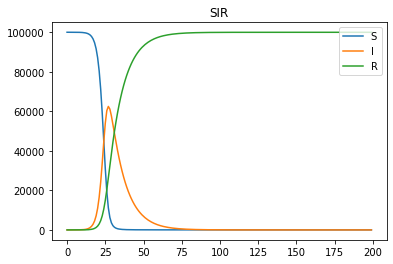

In [44]:
# Plotting SIR
plot_SIR(SIR_obs)

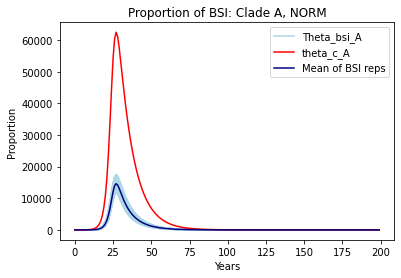

In [48]:
# Plotting I (colonization) and BSI:

plot_col_to_BSI(SIR_obs, or_data = or_data, clade = "A", dataset = "NORM", n_rep = 100, theta_c = 1, theta_bsi = 0.3, is_prop = False)

In [15]:
def I_max(y):
    # y: SIR, tuple consisting of (S,I,R)
    return np.max(y[1][:,], axis = 1)

I_max(SIR_obs)

array([0.62469251, 0.62469251])

In [10]:
# summaries for I:

def I_max_t(y):
    # For aggregated data only
    I = y[1]
    batch_size = I.shape[0]


    max_t = np.zeros((batch_size,))
    bi = 0
    for b in I:
        i, = np.where(np.isclose(b, np.max(b))) # assumes a unique max value
        max_t[bi] = i
        bi += 1
        
    return max_t

def I_max_t_year(y):
    # TODO: same as I_max_t, but round to the nearest year.
    # note: only for SIR
    
    I = y[1]
    batch_size = I.shape[0]


    max_t = np.zeros((batch_size,))
    bi = 0
    for b in I:
        i, = np.where(np.isclose(b, np.max(b))) # assumes a unique max value
        max_t[bi] = np.ceil(i/52)
        bi += 1
        
    return max_t

def I_max(y):
    
    return np.max(y[1][:,], axis = 1)

print(I_max_t(SIR_obs)) 

# problem: resolution. The observed data is yearly, simulation is weekly. So we probably should have a tolerance of 52 weeks here. 
# with aggregated data, this is not an issue, since we are on the same scale. However: this might not be informative enough.

print(I_max(SIR_obs))

#SIR_obs.index(np.max(SIR_obs[1][:,], axis = 1))

print(I_max_t_year(SIR_obs))

[27. 27.]
[0.62469251 0.62469251]
[1. 1.]


In [94]:
np.ceil(27/52)

1.0

In [92]:
I = SIR_obs[1]
batch_size = I.shape[0]


max_t = np.zeros((batch_size,))
bi = 0
for b in I:
    i, = np.where(np.isclose(b, np.max(b))) # assumes a unique max value
    max_t[bi] = np.ceil(i/52)
    bi += 1

print(max_t.shape) # should be (batch_size, )
print(max_t)

[27.]
[27.]
(2,)
[1. 1.]


In [43]:
print(j.shape) # (bs,)

(1,)
